# tkh-phase-2-project - Financial Fraud Detection - Explore notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Load data

In [2]:
df_orig = pd.read_csv('../data/PS_20174392719_1491204439457_log.csv')

## Summary stats

In [3]:
df_orig.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


Above, we see that we have 11 columns, consisting of 10 features/predictors and one target (`isFraud`). We also see that we have 6.36 million rows and no null/missing values.

In [4]:
df_orig.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


## Rename columns for ease of readability

In [5]:
df = df_orig.copy()
df.columns.to_list()

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud']

In [25]:
# Copied above cell output and revised it accordingly
df.columns = [
    'step',
    'type',
    'amount',
    'name_orig',
    'old_balance_orig',
    'new_balance_orig',
    'name_dest',
    'old_balance_dest',
    'new_balance_dest',
    'is_fraud',
    'is_flagged_fraud'
]

## Numeric features

In [7]:
df_num = df.select_dtypes(include=np.number)
df_num.head()

,step,amount,old_balance_orig,new_balance_orig,old_balance_dest,new_balance_dest,is_fraud,is_flagged_fraud
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,181.00,181.0,0.00,0.0,0.0,1,0
3,1,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0


In [8]:
df_num.describe()

,step,amount,old_balance_orig,new_balance_orig,old_balance_dest,new_balance_dest,is_fraud,is_flagged_fraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


Above, we see that minimum of the `amount` feature is zero. Transactions of zero money don't seem like valid transactions. Keeping them in the dataset can make it hard to apply log transforms (because log(0) equals neg infinity) so let's inspect how many rows have a zero `amount`.

In [9]:
df_amount_zero = df_num[df_num['amount'] == 0]
df_amount_zero.info()

<class 'pandas.DataFrame'>
Index: 16 entries, 2736447 to 6362585
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   step              16 non-null     int64  
 1   amount            16 non-null     float64
 2   old_balance_orig  16 non-null     float64
 3   new_balance_orig  16 non-null     float64
 4   old_balance_dest  16 non-null     float64
 5   new_balance_dest  16 non-null     float64
 6   is_fraud          16 non-null     int64  
 7   is_flagged_fraud  16 non-null     int64  
dtypes: float64(5), int64(3)
memory usage: 1.1 KB


In [10]:
df_amount_zero

,step,amount,old_balance_orig,new_balance_orig,old_balance_dest,new_balance_dest,is_fraud,is_flagged_fraud
2736447,212,0.0,0.0,0.0,0.00,0.00,1,0
3247298,250,0.0,0.0,0.0,0.00,0.00,1,0
3760289,279,0.0,0.0,0.0,538547.63,538547.63,1,0
5563714,387,0.0,0.0,0.0,7970766.57,7970766.57,1,0
5996408,425,0.0,0.0,0.0,76759.90,76759.90,1,0
5996410,425,0.0,0.0,0.0,2921531.34,2921531.34,1,0
6168500,554,0.0,0.0,0.0,230289.66,230289.66,1,0
6205440,586,0.0,0.0,0.0,1328472.86,1328472.86,1,0
6266414,617,0.0,0.0,0.0,0.00,0.00,1,0
6281483,646,0.0,0.0,0.0,0.00,0.00,1,0


Above, we see that there are 16 rows where `amount` equals zero. Since all 16 rows are labeled as fraud, let's keep the rows for now.

In [11]:
df_num['is_fraud'].value_counts()

is_fraud
0    6354407
1       8213
Name: count, dtype: int64

Above, we see that just how small our minority class is. There are 8,213 fraud transactions and 6.35 million non-fraud transactions.

In [12]:
df_num['step'].value_counts()

step
19     51352
18     49579
187    49083
235    47491
307    46968
       ...  
721        4
725        4
729        4
112        2
662        2
Name: count, Length: 743, dtype: int64

It's not clear how useful the `step` feature will be. It's an integer between (1, 743) and it represents when the point in time the transaction occurred, with larger values signifying that a transaction occurred later. By looking at the `value_counts()`, we see that some steps had 40-50K transactions, while others had under 5 transactions.

## Non-numeric features

In [13]:
df_non_num = df.select_dtypes(exclude=np.number)
df_non_num

,type,name_orig,name_dest
0,PAYMENT,C1231006815,M1979787155
1,PAYMENT,C1666544295,M2044282225
2,TRANSFER,C1305486145,C553264065
3,CASH_OUT,C840083671,C38997010
4,PAYMENT,C2048537720,M1230701703
...,...,...,...
6362615,CASH_OUT,C786484425,C776919290
6362616,TRANSFER,C1529008245,C1881841831
6362617,CASH_OUT,C1162922333,C1365125890
6362618,TRANSFER,C1685995037,C2080388513


In [14]:
df_non_num['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

The `type` feature contains a small number of values that could have predictive power, so let's encode this column with `get_dummies`.

In [26]:
df_dummies = pd.get_dummies(df_non_num['type'], drop_first=True)
df_dummies.columns = [c.lower() for c in df_clean.columns.to_list()]
df_dummies

,cash_out,debit,payment,transfer
0,False,False,True,False
1,False,False,True,False
2,False,False,False,True
3,True,False,False,False
4,False,False,True,False
...,...,...,...,...
6362615,True,False,False,False
6362616,False,False,False,True
6362617,True,False,False,False
6362618,False,False,False,True


In [27]:
df_non_num['name_orig'].value_counts()

name_orig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
              ..
C786484425     1
C1529008245    1
C1162922333    1
C1685995037    1
C1280323807    1
Name: count, Length: 6353307, dtype: int64

In [28]:
df_non_num['name_dest'].value_counts()

name_dest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
              ... 
C1812552860      1
C1470998563      1
C1850423904      1
C1881841831      1
C2080388513      1
Name: count, Length: 2722362, dtype: int64

Above, we see that `values_counts()` of the `nameOrig` and `nameDest` features. These features are of string datatype. If we were to use these features with our models, we'd need them to be formatted as a number. It's not clear how helpful they will be for our predictions since they just identify bank accounts. It is concievable that some accounts are more prone to fraud. Perhaps it is helpful for the model to learn which accounts have had fraud in case the model encounters those accounts again in other transactions.

One way to format these features as number is the substitute the leading 'C' or 'M' with the digit 1 or 2.

In [18]:
df_non_num2 = df_non_num.copy()
df_non_num2['name_orig'] = df_non_num2['name_orig'].str.replace('C', '1')
df_non_num2['name_orig'] = df_non_num2['name_orig'].str.replace('M', '2')
df_non_num2['name_orig'] = df_non_num2['name_orig'].astype(int)
df_non_num2['name_orig'].value_counts()

name_orig
12098525306    3
1400299098     3
11999539787    3
11065307291    3
1545315117     3
              ..
1786484425     1
11529008245    1
11162922333    1
11685995037    1
11280323807    1
Name: count, Length: 6353307, dtype: int64

In [19]:
df_non_num2['name_dest'] = df_non_num2['name_dest'].str.replace('C', '1')
df_non_num2['name_dest'] = df_non_num2['name_dest'].str.replace('M', '2')
df_non_num2['name_dest'] = df_non_num2['name_dest'].astype(int)
df_non_num2['name_dest'].value_counts()

name_dest
11286084959    113
1985934102     109
1665576141     105
12083562754    102
1248609774     101
              ... 
11812552860      1
11470998563      1
11850423904      1
11881841831      1
12080388513      1
Name: count, Length: 2722362, dtype: int64

The two cells above show that replacing the C's and M's gives us numeric data. A quick comparison of the value counts from before and after the replacements shows that no information was lost.

## Univariate analysis

In [20]:
columns = df_num.columns.to_list()
columns

['step',
 'amount',
 'old_balance_orig',
 'new_balance_orig',
 'old_balance_dest',
 'new_balance_dest',
 'is_fraud',
 'is_flagged_fraud']

In [29]:
# Copied output from above cell and trimmed it down to just the columns of interest
columns = [
    'step',
    'amount',
    'old_balance_orig',
    'new_balance_orig',
    'old_balance_dest',
    'new_balance_dest',
]

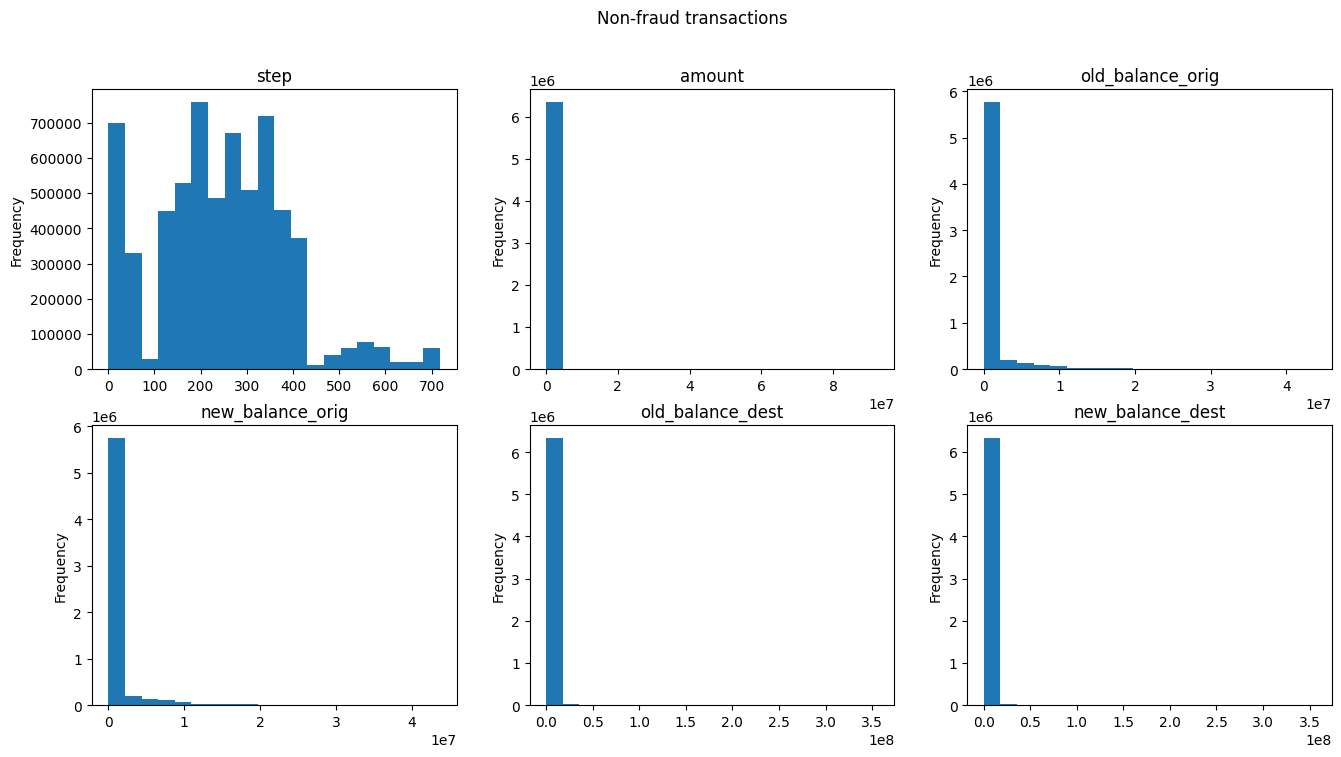

In [22]:
nrows = 2
ncols = 3
title = 'Non-fraud transactions'

figure, axes = plt.subplots(nrows, ncols, figsize=(16, 8))
figure.suptitle(title)
for col, ax in zip(columns, axes.flatten()):
    df_num[df_num['is_fraud'] == 0][col].plot.hist(ax=ax, bins=20, title=col)

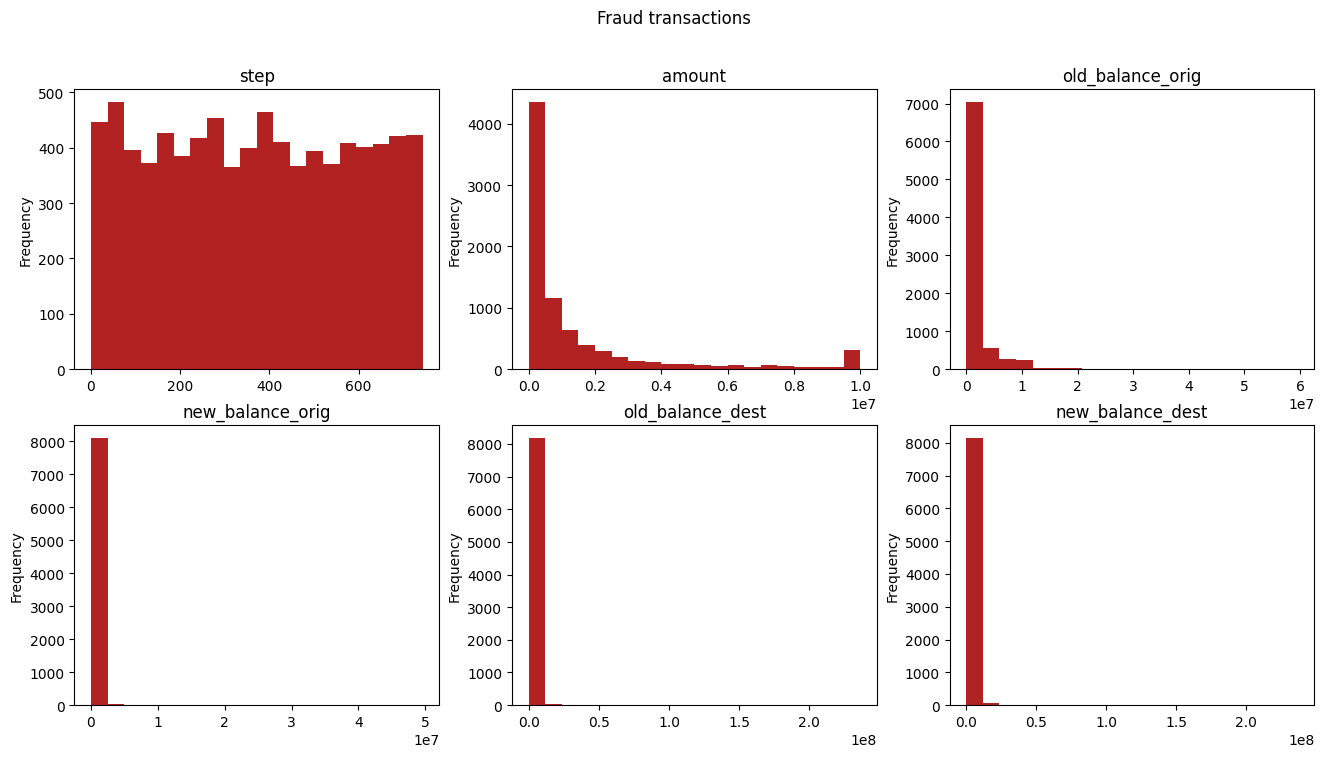

In [23]:
nrows = 2
ncols = 3
title = 'Fraud transactions'

figure, axes = plt.subplots(nrows, ncols, figsize=(16, 8))
figure.suptitle(title)
for col, ax in zip(columns, axes.flatten()):
    df_num[df_num['is_fraud'] == 1][col].plot.hist(ax=ax, bins=20, title=col, color='firebrick')

The histograms above show that our account balance features for all transactions (fraud and non-fraud) are very skewed, with peaks in values between 0 and 2,500,000 in currency units. For the step feature, our histograms are mostly uniformly distributed, more so with the fraud transactions.

## Bivariate analysis

Text(0.5, 1.0, 'Correlation Heatmap')

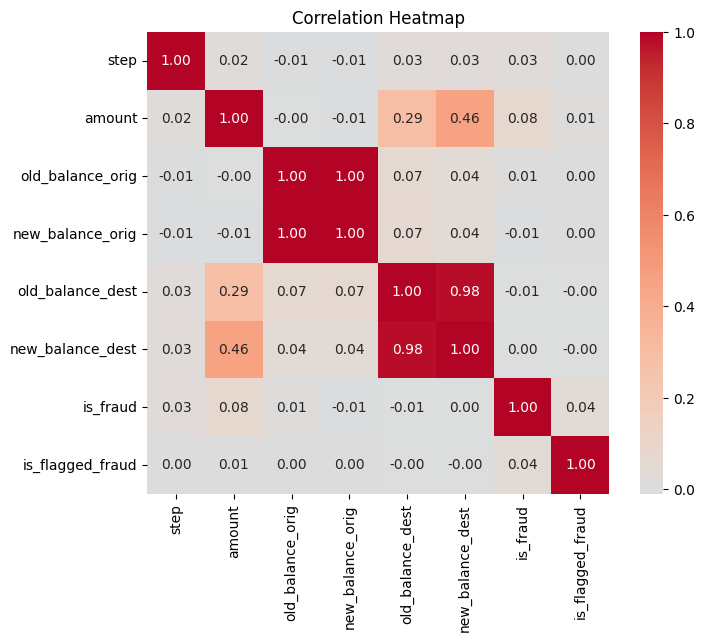

In [24]:
corr = df_num.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap')

Our correlation heatmap above show extreme collinearity between the old and new balances for both the origin and destination accounts. This makes sense because each transaction affects the two accounts by the same amount in opposite directions. 

We also see some but not as much collinearity between amount and the old/new balances for the destination account. This makes sense because amount equals how much the destination account changes in the transaction. It's unclear why there isn't collinearity between amount and the old/new balancaes for the origin account.

Another noteworthy observation is that there is very little correlation between our features and our target (`is_fraud`). The column with most correlation with our target is amount, with a value of 0.08.

## Features to keep/drop

Before training our models, we'll want to drop half of the feature pairs that showed collinearity. In order words, we'll drop:

* `old_balance_orig`
* `old_balance_dest`

We'll drop `step` because the timing of transactions, especially ones as imprecise as only 743 values, doesn't reveal much about the validity of a transaction.

We'll drop `name_orig` and `name_dest` because it's unlikely that bank account identifiers are relevant info.

Finally, we'll drop `is_flagged_fraud` because the assignment instructions mentioned that this column is already captured by the `amount` column.